## THOR Foundation Model — Sentinel-3 Inference using Phidown and download from Copernicus Data Space

Run the pretrained THOR backbone on co-located Sentinel-3 OLCI (21 bands) and
SLSTR (9 bands) data downloaded from the
[Copernicus Data Space Ecosystem](https://dataspace.copernicus.eu/) using
[phidown](https://github.com/FM4CS/phidown).

### Prerequisites

1. **CDSE credentials** — create a free account at dataspace.copernicus.eu, then
   create S3 credentials in your account settings and place them in `~/.s5cfg`:
   ```ini
   [default]
   access_key = YOUR_ACCESS_KEY
   secret_key = YOUR_SECRET_KEY
   ```
2. **s5cmd** — the fast S3 CLI used by phidown for downloads.
   Install with `pip install s5cmd`.

### Default target: Oslo, Norway
Change `TARGET_LAT`, `TARGET_LON`, and `DATE` in the config cell to use a
different location or date.

In [1]:
# !pip install git+https://github.com/fm4cs/thor_terratorch_ext.git
# !pip install 'phidown[jupyter-env,viz]' s5cmd scipy pyproj

In [2]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from numpy.typing import NDArray

from phidown import CopernicusDataSearcher
from phidown.downloader import pull_down

import thor_terratorch_ext  # noqa: F401 — registers THOR backbones
from thor_terratorch_ext.datasets.utils import OLCIBands, SLSTRBands
from terratorch.registry import BACKBONE_REGISTRY
from thor_terratorch_ext.datasets.sentinel3_utils import (
    radiance_to_reflectance,
    interp_tie_points,
    geo_bbox,
    geo_crop_slices,
    fill_nan,
    normalise_for_thor,
)

/home/theodor/Projects/thor_terratorch_ext_claude/.venv/lib/python3.13/site-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/theodor/Projects/thor_terratorch_ext_claude/.venv/lib/python3.13/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
INFO:thor.models.patch_timm:Patching timm Attention and Block to use Alibi...
INFO:thor.models.patch_timm:Using normal attention for timm Attention


In [3]:
# ── Target location & date ────────────────────────────────────────────────
TARGET_LAT = 59.30
TARGET_LON = 10.66
TARGET_NAME = "Oslo, Norway"
DATE = "2022-05-16"
GROUND_COVER = 76_800  # metres — ~256 OLCI pixels at 300 m GSD

# Local directory for downloaded SEN3 scenes
DOWNLOAD_DIR = Path("sentinel3_data").resolve()
DOWNLOAD_DIR.mkdir(exist_ok=True)

# 1° buffer — more than enough for Sentinel-3's ~1270 km OLCI swath
aoi_wkt = (
    f"POLYGON(("
    f"{TARGET_LON - 1} {TARGET_LAT - 1}, "
    f"{TARGET_LON + 1} {TARGET_LAT - 1}, "
    f"{TARGET_LON + 1} {TARGET_LAT + 1}, "
    f"{TARGET_LON - 1} {TARGET_LAT + 1}, "
    f"{TARGET_LON - 1} {TARGET_LAT - 1}"
    f"))"
)

print(f"Target : {TARGET_NAME} ({TARGET_LAT}N, {TARGET_LON}E)")
print(f"Date   : {DATE}")
print(f"Download dir: {DOWNLOAD_DIR}")

Target : Oslo, Norway (59.3N, 10.66E)
Date   : 2022-05-16
Download dir: /home/theodor/Projects/thor_terratorch_ext_claude/notebooks/sentinel3_data


In [4]:
def _start_time(product_name):
    """Extract sensing-start timestamp from a Sentinel-3 product name."""
    m = re.search(r"(\d{8}T\d{6})", product_name)
    return pd.Timestamp(m.group(1)) if m else pd.NaT


def find_s3_pair(aoi_wkt, date, max_gap_min=30):
    """
    Find the best co-located OLCI + SLSTR L1 scene pair for a given date.

    Queries the Copernicus Data Space for both instruments over the AOI
    and returns the pair with the smallest sensing-time gap.

    Returns a dict with keys 'olci', 'slstr', 'gap_min', or None if no
    valid pair is found within *max_gap_min* minutes.
    """
    date_ts = pd.Timestamp(date)
    start = date_ts.strftime("%Y-%m-%dT00:00:00")
    end = date_ts.strftime("%Y-%m-%dT23:59:59")

    def _search(instrument):
        searcher = CopernicusDataSearcher()
        searcher.query_by_filter(
            collection_name="SENTINEL-3",
            aoi_wkt=aoi_wkt,
            start_date=start,
            end_date=end,
            attributes={"instrumentShortName": instrument, "processingLevel": "1"},
            top=100,
        )
        df = searcher.execute_query()
        if not df.empty:
            df["start_time"] = df["Name"].apply(_start_time)
        return df

    print(f"Searching OLCI  over {TARGET_NAME} on {date} ...")
    olci_df = _search("OLCI")
    print(f"  {len(olci_df)} scenes")

    print(f"Searching SLSTR over {TARGET_NAME} on {date} ...")
    slstr_df = _search("SLSTR")
    print(f"  {len(slstr_df)} scenes")

    if olci_df.empty or slstr_df.empty:
        return None

    best = None
    for _, olci_row in olci_df.iterrows():
        gaps = (slstr_df["start_time"] - olci_row["start_time"]).abs()
        idx = gaps.idxmin()
        gap_min = gaps.loc[idx].total_seconds() / 60
        if gap_min <= max_gap_min:
            if best is None or gap_min < best["gap_min"]:
                best = {
                    "olci": olci_row,
                    "slstr": slstr_df.loc[idx],
                    "gap_min": gap_min,
                }

    return best


pair = find_s3_pair(aoi_wkt, DATE)

if pair is None:
    raise RuntimeError(
        f"No OLCI+SLSTR pair found on {DATE} over {TARGET_NAME}. Try a different date."
    )

print(f"\nSelected pair  (gap: {pair['gap_min']:.1f} min)")
print(f"  OLCI : {pair['olci']['Name']}")
print(f"  SLSTR: {pair['slstr']['Name']}")

Searching OLCI  over Oslo, Norway on 2022-05-16 ...
  4 scenes
Searching SLSTR over Oslo, Norway on 2022-05-16 ...
  6 scenes

Selected pair  (gap: 0.0 min)
  OLCI : S3B_OL_1_EFR____20220516T101549_20220516T101848_20240523T231101_0179_066_065_1980_MAR_R_NT_004.SEN3
  SLSTR: S3B_SL_1_RBT____20220516T101549_20220516T101849_20220517T004307_0180_066_065_1980_PS2_O_NT_004.SEN3


In [5]:
# pull_down creates {DOWNLOAD_DIR}/{product_name}.SEN3/ and fills it with
# the scene's files (uses s5cmd under the hood; requires ~/.s5cfg credentials).

# Locate the s5cmd config file — check common locations
_s5cfg_candidates = [
    Path.home() / ".s5cfg",  # standard location (~/.s5cfg)
    Path(".s5cfg").resolve(),  # project root (if running from there)
    Path("../.s5cfg").resolve(),  # project root (if running from notebooks/)
]
S5CFG = next((p for p in _s5cfg_candidates if p.exists()), None)
if S5CFG is None:
    raise FileNotFoundError(
        "Could not find .s5cfg credentials file. "
        "Place it at ~/.s5cfg or in the project root."
    )
print(f"Using credentials: {S5CFG}")

olci_dir = DOWNLOAD_DIR / f"{pair['olci']['Name']}"
slstr_dir = DOWNLOAD_DIR / f"{pair['slstr']['Name']}"

if olci_dir.exists():
    print(f"OLCI  already downloaded: {olci_dir.name}")
else:
    print("Downloading OLCI ...")
    pull_down(
        pair["olci"]["S3Path"], output_dir=str(DOWNLOAD_DIR), config_file=str(S5CFG)
    )

if slstr_dir.exists():
    print(f"SLSTR already downloaded: {slstr_dir.name}")
else:
    print("Downloading SLSTR ...")
    pull_down(
        pair["slstr"]["S3Path"], output_dir=str(DOWNLOAD_DIR), config_file=str(S5CFG)
    )

print(f"\nOLCI  dir : {olci_dir}")
print(f"SLSTR dir : {slstr_dir}")

Using credentials: /home/theodor/Projects/thor_terratorch_ext_claude/.s5cfg
OLCI  already downloaded: S3B_OL_1_EFR____20220516T101549_20220516T101848_20240523T231101_0179_066_065_1980_MAR_R_NT_004.SEN3
SLSTR already downloaded: S3B_SL_1_RBT____20220516T101549_20220516T101849_20220517T004307_0180_066_065_1980_PS2_O_NT_004.SEN3

OLCI  dir : /home/theodor/Projects/thor_terratorch_ext_claude/notebooks/sentinel3_data/S3B_OL_1_EFR____20220516T101549_20220516T101848_20240523T231101_0179_066_065_1980_MAR_R_NT_004.SEN3
SLSTR dir : /home/theodor/Projects/thor_terratorch_ext_claude/notebooks/sentinel3_data/S3B_SL_1_RBT____20220516T101549_20220516T101849_20220517T004307_0180_066_065_1980_PS2_O_NT_004.SEN3


**Full-accuracy NetCDF pipeline** (downloaded SEN3 scenes)::


    olci_refl, _ = load_olci_reflectance(scene_dir)        # (21, H, W)
    slstr_refl   = load_slstr_reflectance(slstr_dir)       # (6, H, W)
    slstr_bt     = load_slstr_bt(slstr_dir)                # (3, H_in, W_in)

In [6]:
# ── OLCI NetCDF loading ────────────────────────────────────────────────────────


def load_olci_reflectance(
    scene_dir: str | Path,
) -> tuple[NDArray, list[str]]:
    """Load all 21 OLCI bands from a downloaded SEN3 scene directory.

    Performs the full accurate conversion pipeline:

    1. Reads per-band radiance from ``Oa{nn}_radiance.nc``.
    2. Reads solar zenith angle from ``tie_geometries.nc`` and interpolates
       it to the full-resolution grid.
    3. Reads per-detector solar irradiance from ``instrument_data.nc`` and
       looks up per-pixel values via the detector index.
    4. Converts to TOA reflectance: ρ = π·L / (F₀·cos(SZA)).
    5. Masks invalid pixels (detector index < 0) to NaN.

    Parameters
    ----------
    scene_dir:
        Path to the SEN3 scene directory (contains ``Oa01_radiance.nc`` etc.).

    Returns
    -------
    reflectance : np.ndarray, shape (21, H, W), dtype float32
        TOA reflectance clipped to [0, 2]; NaN where pixels are invalid.
    band_names : list[str]
        THOR-convention band names, e.g. ``['Oa01_reflectance', ...]``.
    """
    import xarray as xr

    scene_dir = Path(scene_dir)

    # Spatial shape from the first band
    sample = xr.open_dataset(scene_dir / "Oa01_radiance.nc", mask_and_scale=True)
    target_shape = sample["Oa01_radiance"].values.shape

    # Solar zenith angle on the full-resolution grid
    cos_sza = _load_olci_cos_sza(scene_dir, target_shape)

    # Per-detector solar irradiance and detector index
    instr = xr.open_dataset(scene_dir / "instrument_data.nc", mask_and_scale=False)
    solar_flux = instr["solar_flux"].values.astype(np.float32)  # (21, n_det)
    det_index = instr["detector_index"].values.astype(np.intp)  # (H, W)
    det_idx_safe = np.clip(det_index, 0, solar_flux.shape[1] - 1)

    arrays = []
    for i in range(1, 22):
        name = f"Oa{i:02d}_radiance"
        ds = xr.open_dataset(scene_dir / f"{name}.nc", mask_and_scale=True)
        radiance = ds[name].values.astype(np.float32)

        f0 = solar_flux[i - 1][det_idx_safe]  # (H, W) per-pixel irradiance
        refl = radiance_to_reflectance(radiance, f0, cos_sza)
        refl = np.where(det_index >= 0, refl, np.nan)
        arrays.append(refl)

    band_names = [f"Oa{i:02d}_reflectance" for i in range(1, 22)]
    return np.stack(arrays, axis=0), band_names


def _load_olci_cos_sza(scene_dir: Path, target_shape: tuple[int, int]) -> NDArray:
    """Load SZA from OLCI tie_geometries.nc and interpolate to *target_shape*."""
    import xarray as xr

    ds = xr.open_dataset(scene_dir / "tie_geometries.nc", mask_and_scale=True)
    sza_tie = ds["SZA"].values.astype(np.float64)
    sza_full = interp_tie_points(sza_tie, target_shape)
    return np.clip(np.cos(np.deg2rad(sza_full)), 0.01, None).astype(np.float32)


def load_olci_geo(
    scene_dir: str | Path,
) -> tuple[NDArray, NDArray]:
    """Load OLCI geodetic coordinates interpolated to the full-resolution grid.

    Reads the tie-point grid from ``tie_geo_coordinates.nc`` and bilinearly
    interpolates latitude and longitude to the full spatial resolution
    (derived from ``Oa01_radiance.nc``).

    Parameters
    ----------
    scene_dir:
        Path to the SEN3 scene directory.

    Returns
    -------
    lat, lon : np.ndarray, shape (H, W), dtype float32
        Latitude and longitude on the full-resolution OLCI grid.
    """
    import xarray as xr

    scene_dir = Path(scene_dir)
    sample = xr.open_dataset(scene_dir / "Oa01_radiance.nc", mask_and_scale=True)
    target_shape = sample["Oa01_radiance"].values.shape

    ds_geo = xr.open_dataset(scene_dir / "tie_geo_coordinates.nc", mask_and_scale=True)
    lat = interp_tie_points(ds_geo["latitude"].values.astype(np.float64), target_shape)
    lon = interp_tie_points(ds_geo["longitude"].values.astype(np.float64), target_shape)
    return lat, lon


# ── SLSTR NetCDF loading ───────────────────────────────────────────────────────


def load_slstr_reflectance(
    scene_dir: str | Path,
) -> NDArray:
    """Load SLSTR solar channels (S1-S6) from a downloaded SEN3 scene directory.

    Performs the full accurate conversion pipeline:

    1. Reads radiance from ``S{i}_radiance_an.nc``.
    2. Reads solar zenith angle from ``geometry_tn.nc`` and interpolates to
       the 500 m nadir grid.
    3. Reads per-detector solar irradiance from ``S{i}_quality_an.nc`` and
       looks up per-pixel values via ``indices_an.nc``.  Falls back to
       :data:`SLSTR_SOLAR_FLUX` tabulated values if ancillary files are absent.
    4. Converts to TOA reflectance: ρ = π·L / (F₀·cos(SZA)).
    5. Masks invalid pixels to NaN.

    Parameters
    ----------
    scene_dir:
        Path to the SEN3 scene directory.

    Returns
    -------
    np.ndarray, shape (6, H, W), dtype float32
        TOA reflectance for S1-S6, clipped to [0, 2]; NaN for invalid pixels.
    """
    import xarray as xr

    scene_dir = Path(scene_dir)

    sample = xr.open_dataset(scene_dir / "S1_radiance_an.nc", mask_and_scale=True)
    target_shape = sample["S1_radiance_an"].values.shape

    cos_sza = _load_slstr_cos_sza(scene_dir, target_shape)

    # Detector indices for per-pixel irradiance lookup and invalid-pixel masking
    indices_path = scene_dir / "indices_an.nc"
    if indices_path.exists():
        ind_ds = xr.open_dataset(indices_path)
        detectors = ind_ds["detector_an"].values
        valid_mask = ~np.isnan(detectors)
        det_idx = np.nan_to_num(detectors, nan=0).astype(np.uint8)
    else:
        valid_mask = None
        det_idx = None

    arrays = []
    for i in range(1, 7):
        name = f"S{i}_radiance_an"
        ds = xr.open_dataset(scene_dir / f"{name}.nc", mask_and_scale=True)
        radiance = ds[name].values.astype(np.float32)

        quality_path = scene_dir / f"S{i}_quality_an.nc"
        if quality_path.exists() and det_idx is not None:
            qds = xr.open_dataset(quality_path)
            irr_per_det = qds[f"S{i}_solar_irradiance_an"].values  # (n_detectors,)
            f0 = irr_per_det[det_idx]  # (H, W)
        else:
            f0 = SLSTR_SOLAR_FLUX[i - 1]

        refl = radiance_to_reflectance(radiance, f0, cos_sza)
        if valid_mask is not None:
            refl = np.where(valid_mask, refl, np.nan)
        arrays.append(refl)

    return np.stack(arrays, axis=0)


def load_slstr_bt(scene_dir: str | Path) -> NDArray:
    """Load SLSTR thermal channels (S7-S9) as brightness temperature (K).

    Parameters
    ----------
    scene_dir:
        Path to the SEN3 scene directory.

    Returns
    -------
    np.ndarray, shape (3, H_in, W_in), dtype float32
        Brightness temperature in Kelvin on the 1 km nadir (``_in``) grid.
    """
    import xarray as xr

    scene_dir = Path(scene_dir)
    arrays = []
    for i in range(7, 10):
        name = f"S{i}_BT_in"
        ds = xr.open_dataset(scene_dir / f"{name}.nc", mask_and_scale=True)
        arrays.append(ds[name].values.astype(np.float32))
    return np.stack(arrays, axis=0)


def load_slstr_geo(
    scene_dir: str | Path,
) -> tuple[NDArray | None, NDArray | None, NDArray | None, NDArray | None]:
    """Load SLSTR geodetic coordinates for the nadir 500 m and 1 km grids.

    Parameters
    ----------
    scene_dir:
        Path to the SEN3 scene directory.

    Returns
    -------
    lat_an, lon_an : np.ndarray or None
        Latitude/longitude on the 500 m nadir grid (S1-S6).
    lat_in, lon_in : np.ndarray or None
        Latitude/longitude on the 1 km nadir grid (S7-S9).
    """
    import xarray as xr

    scene_dir = Path(scene_dir)
    lat_an = lon_an = lat_in = lon_in = None

    an_path = scene_dir / "geodetic_an.nc"
    if an_path.exists():
        ds = xr.open_dataset(an_path, mask_and_scale=True)
        lat_an = ds["latitude_an"].values
        lon_an = ds["longitude_an"].values

    in_path = scene_dir / "geodetic_in.nc"
    if in_path.exists():
        ds = xr.open_dataset(in_path, mask_and_scale=True)
        lat_in = ds["latitude_in"].values
        lon_in = ds["longitude_in"].values

    return lat_an, lon_an, lat_in, lon_in


def _load_slstr_cos_sza(scene_dir: Path, target_shape: tuple[int, int]) -> NDArray:
    """Load SZA from SLSTR geometry_tn.nc and interpolate to *target_shape*."""
    import xarray as xr

    ds = xr.open_dataset(scene_dir / "geometry_tn.nc", mask_and_scale=True)
    sza_tie = ds["solar_zenith_tn"].values.astype(np.float64)
    sza_full = interp_tie_points(sza_tie, target_shape)
    return np.clip(np.cos(np.deg2rad(sza_full)), 0.01, None).astype(np.float32)

In [7]:
crop_bbox = geo_bbox(TARGET_LAT, TARGET_LON, GROUND_COVER)

# ── OLCI ──────────────────────────────────────────────────────────────────
print("Loading OLCI ...")
olci_data, olci_band_names = load_olci_reflectance(olci_dir)
lat, lon = load_olci_geo(olci_dir)

row_sl, col_sl = geo_crop_slices(lat, lon, crop_bbox)
if row_sl is None:
    H, W = olci_data.shape[1:]
    row_sl = slice(H // 2 - 128, H // 2 + 128)
    col_sl = slice(W // 2 - 128, W // 2 + 128)
    print("  Target not in scene — using centre crop")

olci_crop = fill_nan(olci_data[:, row_sl, col_sl])
CROP_SIZE = olci_crop.shape[1]
print(
    f"  {olci_crop.shape}  lat [{lat[row_sl, col_sl].min():.2f}, {lat[row_sl, col_sl].max():.2f}]"
)

# ── SLSTR ──────────────────────────────────────────────────────────────────
print("Loading SLSTR ...")
slstr_refl_full = load_slstr_reflectance(slstr_dir)
slstr_bt_full = load_slstr_bt(slstr_dir)
lat_an, lon_an, lat_in, lon_in = load_slstr_geo(slstr_dir)

refl_row_sl, refl_col_sl = geo_crop_slices(lat_an, lon_an, crop_bbox, min_size=16)
bt_row_sl, bt_col_sl = geo_crop_slices(lat_in, lon_in, crop_bbox, min_size=8)

slstr_refl = fill_nan(
    slstr_refl_full[:, refl_row_sl, refl_col_sl] if refl_row_sl else slstr_refl_full
)
slstr_bt = fill_nan(
    slstr_bt_full[:, bt_row_sl, bt_col_sl] if bt_row_sl else slstr_bt_full
)
print(f"  refl {slstr_refl.shape}, bt {slstr_bt.shape}")

Loading OLCI ...


/home/theodor/Projects/thor_terratorch_ext_claude/.venv/lib/python3.13/site-packages/xarray/namedarray/core.py:261: UserWarning: Duplicate dimension names present: dimensions {'bands'} appear more than once in dims=('bands', 'bands'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.
  self._dims = self._parse_dimensions(dims)
/home/theodor/Projects/thor_terratorch_ext_claude/.venv/lib/python3.13/site-packages/xarray/namedarray/core.py:261: UserWarning: Duplicate dimension names present: dimensions {'bands'} appear more than once in dims=('bands', 'bands'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the 

  (21, 332, 361)  lat [58.74, 59.85]
Loading SLSTR ...
  refl (6, 194, 194), bt (3, 97, 97)


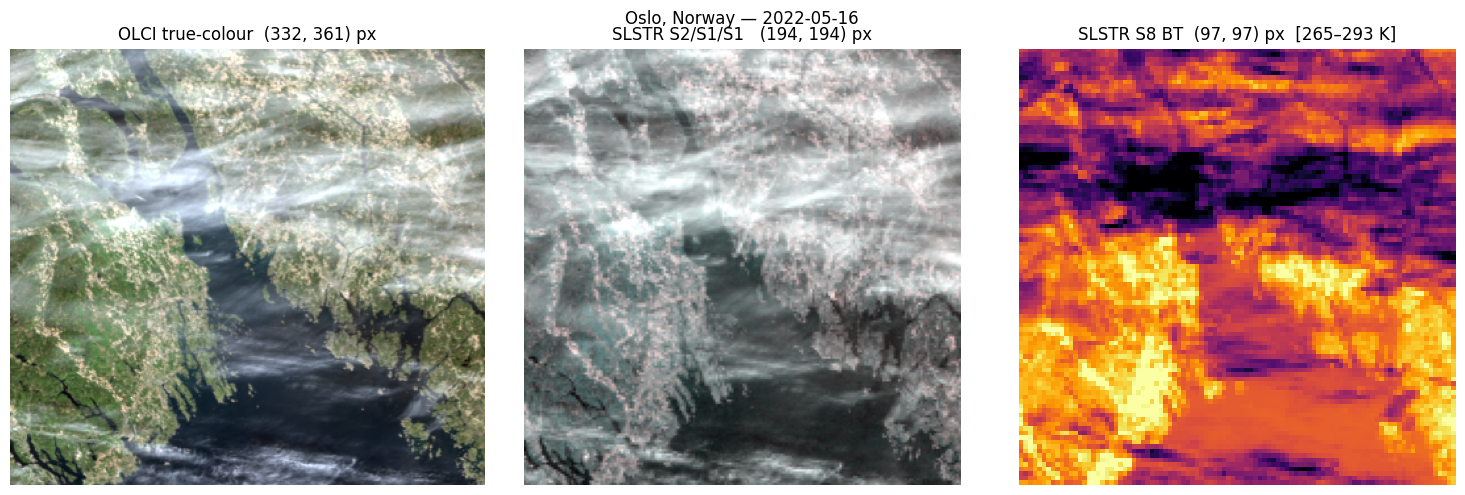

In [8]:
from terratorch.datasets.utils import to_rgb

olci_rgb = to_rgb(olci_crop, [7, 5, 3])
slstr_rgb = to_rgb(slstr_refl, [1, 0, 0])
s8_bt = slstr_bt[1]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(olci_rgb)
axes[0].set_title(f"OLCI true-colour  {olci_crop.shape[1:]} px")
axes[0].axis("off")
axes[1].imshow(slstr_rgb)
axes[1].set_title(f"SLSTR S2/S1/S1   {slstr_refl.shape[1:]} px")
axes[1].axis("off")
valid_bt = s8_bt[~np.isnan(s8_bt)]
vmin, vmax = np.percentile(valid_bt, [2, 98]) if len(valid_bt) else (0, 1)
axes[2].imshow(s8_bt, vmin=vmin, vmax=vmax, cmap="inferno")
axes[2].set_title(f"SLSTR S8 BT  {slstr_bt.shape[1:]} px  [{vmin:.0f}–{vmax:.0f} K]")
axes[2].axis("off")
fig.suptitle(f"{TARGET_NAME} — {DATE}", fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
# ── Band lists ─────────────────────────────────────────────────────────────
ALL_OLCI_BANDS = [b.value for b in OLCIBands]
SLSTR_REFL_BANDS = [b.value for b in SLSTRBands if "REFLECTANCE" in b.value]
SLSTR_BT_BANDS = [b.value for b in SLSTRBands if "BT" in b.value]
ALL_SLSTR_BANDS = SLSTR_REFL_BANDS + SLSTR_BT_BANDS

# ── Normalise using THOR pretraining statistics ────────────────────────────
olci_n = normalise_for_thor(olci_crop, ALL_OLCI_BANDS)
slstr_refl_n = normalise_for_thor(slstr_refl, SLSTR_REFL_BANDS)
slstr_bt_n = normalise_for_thor(slstr_bt, SLSTR_BT_BANDS)


# Upscale SLSTR to OLCI spatial size for stacking
def _upscale(arr, h, w):
    t = torch.from_numpy(arr).unsqueeze(0).float()
    return (
        F.interpolate(t, size=(h, w), mode="bilinear", align_corners=False)
        .squeeze(0)
        .numpy()
    )


H, W = olci_crop.shape[1:]
mm = (
    torch.from_numpy(
        np.concatenate(
            [olci_n, _upscale(slstr_refl_n, H, W), _upscale(slstr_bt_n, H, W)], axis=0
        )
    )
    .unsqueeze(0)
    .float()
)
print(f"Input tensor: {mm.shape}  (1, 21 OLCI + 6 SLSTR-refl + 3 SLSTR-BT, H, W)")

# ── Build backbone ─────────────────────────────────────────────────────────

backbone = BACKBONE_REGISTRY.build(
    "thor_v1_small",
    pretrained=True,
    model_bands=ALL_OLCI_BANDS + ALL_SLSTR_BANDS,
    input_params=dict(ground_covers=[GROUND_COVER], flexivit_patch_size_seqs=[8]),
    merge_method="mean",
)
print(f"Backbone: {len(backbone.bands)} bands, {len(backbone.groups)} groups")
for name, members in backbone.groups.items():
    gsd = backbone.channels[members[0]]["GSD"]
    print(
        f"  {name}: {len(members)} bands @ {gsd} m GSD → {GROUND_COVER // gsd // 8} patches/side"
    )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
backbone = backbone.to(device).eval()
mm = mm.to(device)

with torch.no_grad():
    features = backbone(mm)

print(f"\nOutput: {len(features)} layers")
for i, f in enumerate(features):
    print(f"  Layer {i + 1:2d}: {tuple(f.shape)}")

/home/theodor/Projects/thor_terratorch_ext_claude/.venv/lib/python3.13/site-packages/terratorch/registry/registry.py:174: UserWarning: Overwriting input param ground_covers for model encoder with [76800]
  return self._registry[name](*constructor_args, **constructor_kwargs)
/home/theodor/Projects/thor_terratorch_ext_claude/.venv/lib/python3.13/site-packages/terratorch/registry/registry.py:174: UserWarning: Overwriting input param flexivit_patch_size_seqs for model encoder with [8]
  return self._registry[name](*constructor_args, **constructor_kwargs)
INFO:thor_terratorch_ext.models.backbones.thor_vit:Using pretrained weights for model encoder


INFO:httpx:HTTP Request: HEAD https://huggingface.co/FM4CS/THOR-1.0-small/resolve/main/thor_v1_vit_small.pt "HTTP/1.1 302 Found"
INFO:thor_terratorch_ext.models.backbones.thor_vit:Instantiating model encoder of type thor_vit_small_encoder_alibi_patch_size_embed_v1
INFO:thor.models.thor_vit:Found bands: ['S2:Red', 'S2:Green', 'S2:Blue', 'S2:NIR', 'S2:RE1', 'S2:RE2', 'S2:RE3', 'S2:RE4', 'S2:SWIR1', 'S2:SWIR2', 'S2:CoastAerosal', 'S2:WaterVapor', 'S1:IW-VH', 'S1:IW-VV', 'S1:EW-VH', 'S1:EW-VV', 'S1:IW-HV', 'S1:IW-HH', 'S1:EW-HV', 'S1:EW-HH', 'S3:Oa01_reflectance', 'S3:Oa02_reflectance', 'S3:Oa03_reflectance', 'S3:Oa04_reflectance', 'S3:Oa05_reflectance', 'S3:Oa06_reflectance', 'S3:Oa07_reflectance', 'S3:Oa08_reflectance', 'S3:Oa09_reflectance', 'S3:Oa10_reflectance', 'S3:Oa11_reflectance', 'S3:Oa12_reflectance', 'S3:Oa13_reflectance', 'S3:Oa14_reflectance', 'S3:Oa15_reflectance', 'S3:Oa16_reflectance', 'S3:Oa17_reflectance', 'S3:Oa18_reflectance', 'S3:Oa19_reflectance', 'S3:Oa20_reflectanc

Input tensor: torch.Size([1, 30, 332, 361])  (1, 21 OLCI + 6 SLSTR-refl + 3 SLSTR-BT, H, W)


INFO:thor.utils.patch_embed:product_band: S2:Red, _patch_size_seq: [8]

INFO:thor.utils.patch_embed:product_band: S2:Green, _patch_size_seq: [8]

INFO:thor.utils.patch_embed:product_band: S2:Blue, _patch_size_seq: [8]

INFO:thor.utils.patch_embed:product_band: S2:NIR, _patch_size_seq: [8]

INFO:thor.utils.patch_embed:product_band: S2:RE1, _patch_size_seq: [8]

INFO:thor.utils.patch_embed:product_band: S2:RE2, _patch_size_seq: [8]

INFO:thor.utils.patch_embed:product_band: S2:RE3, _patch_size_seq: [8]

INFO:thor.utils.patch_embed:product_band: S2:RE4, _patch_size_seq: [8]

INFO:thor.utils.patch_embed:product_band: S2:SWIR1, _patch_size_seq: [8]

INFO:thor.utils.patch_embed:product_band: S2:SWIR2, _patch_size_seq: [8]

INFO:thor.utils.patch_embed:product_band: S2:CoastAerosal, _patch_size_seq: [8]

INFO:thor.utils.patch_embed:product_band: S2:WaterVapor, _patch_size_seq: [8]

INFO:thor.utils.patch_embed:product_band: S1:IW-VV, _patch_size_seq: [8]

INFO:thor.utils.patch_embed:product_ban

Backbone: 30 bands, 5 groups
  group5: 7 bands @ 240 m GSD → 40 patches/side
  group6: 7 bands @ 240 m GSD → 40 patches/side
  group7: 7 bands @ 240 m GSD → 40 patches/side
  group8: 6 bands @ 480 m GSD → 20 patches/side
  group9: 3 bands @ 960 m GSD → 10 patches/side

Output: 12 layers
  Layer  1: (1, 384, 40, 40)
  Layer  2: (1, 384, 40, 40)
  Layer  3: (1, 384, 40, 40)
  Layer  4: (1, 384, 40, 40)
  Layer  5: (1, 384, 40, 40)
  Layer  6: (1, 384, 40, 40)
  Layer  7: (1, 384, 40, 40)
  Layer  8: (1, 384, 40, 40)
  Layer  9: (1, 384, 40, 40)
  Layer 10: (1, 384, 40, 40)
  Layer 11: (1, 384, 40, 40)
  Layer 12: (1, 384, 40, 40)


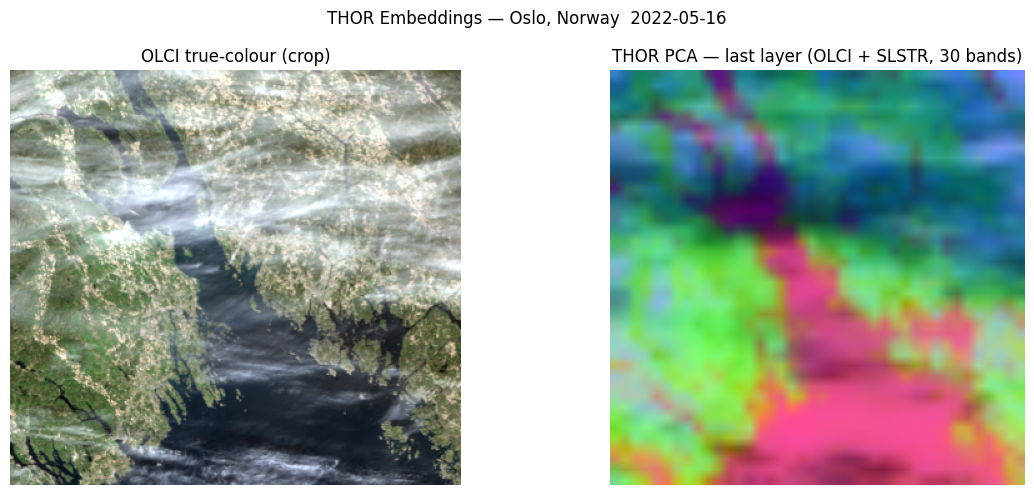

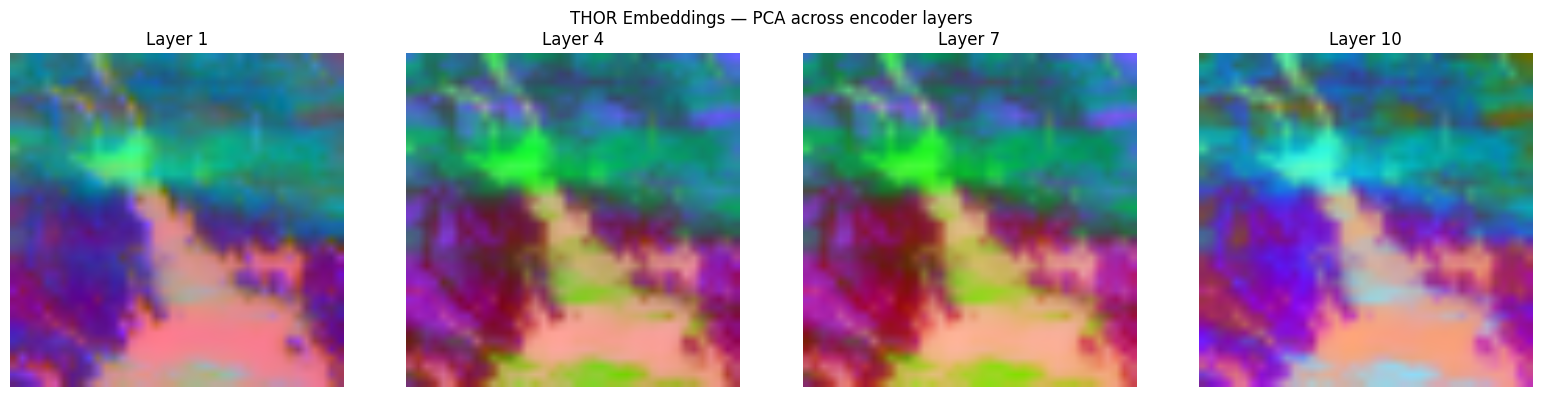

In [10]:
from terratorch.datasets.utils import to_pca_rgb, resize_hwc


def pca_viz(features, step=1):
    """Compute PCA RGB visualisation of a feature layer."""
    # features: (C, H, W) tensor
    pca_rgb, _H, _W = to_pca_rgb(features.cpu().numpy(), step=step)
    return pca_rgb


pca_last = resize_hwc(pca_viz(features[-1][0]), (CROP_SIZE, CROP_SIZE))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(olci_rgb)
axes[0].set_title("OLCI true-colour (crop)")
axes[0].axis("off")
axes[1].imshow(pca_last)
axes[1].set_title("THOR PCA — last layer (OLCI + SLSTR, 30 bands)")
axes[1].axis("off")
fig.suptitle(f"THOR Embeddings — {TARGET_NAME}  {DATE}", fontsize=12)
plt.tight_layout()
plt.show()

# Layer evolution
layer_indices = list(range(0, len(features), 3))
fig, axes = plt.subplots(1, len(layer_indices), figsize=(4 * len(layer_indices), 4))
for ax, idx in zip(axes, layer_indices):
    ax.imshow(resize_hwc(pca_viz(features[idx][0]), (CROP_SIZE, CROP_SIZE)))
    ax.set_title(f"Layer {idx + 1}")
    ax.axis("off")
fig.suptitle("THOR Embeddings — PCA across encoder layers", fontsize=12)
plt.tight_layout()
plt.show()